# Tutorial Denoising

> denoising


In [ ]:
#| default_exp tutorial_denoising

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.losses import SSIMLoss
from bioMONAI.metrics import *
from bioMONAI.datasets import download_file


In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
# Specify the directory where you want to save the downloaded files
output_directory = "../_data/U2OS"
# Define the base URL for the dataset
url = 'http://csbdeep.bioimagecomputing.com/example_data/snr_7_binning_2.zip'

# Download only the first two images
download_file(url, output_directory, extract=True)

The file has been downloaded and saved to: ../_data/U2OS
Decompression (if needed) has been handled automatically.


### Create Dataloader

In [ ]:
X_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/train/low/'

bs = 16
patch_size = 128

itemTfms = [RandCropND(patch_size), RandRot90(prob=.75), RandFlip(prob=0.75)]
batchTfms = [ScaleIntensityPercentiles()]

get_target_fn = get_target('GT', same_filename=True, relative_path=True)

data = BioDataLoaders.from_folder(
    X_path, 
    get_target_fn, 
    valid_pct=0.05, 
    seed=42, 
    item_tfms=itemTfms,
    batch_tfms=batchTfms, 
    show_summary=False,
    bs = bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 2335 
validation images: 122


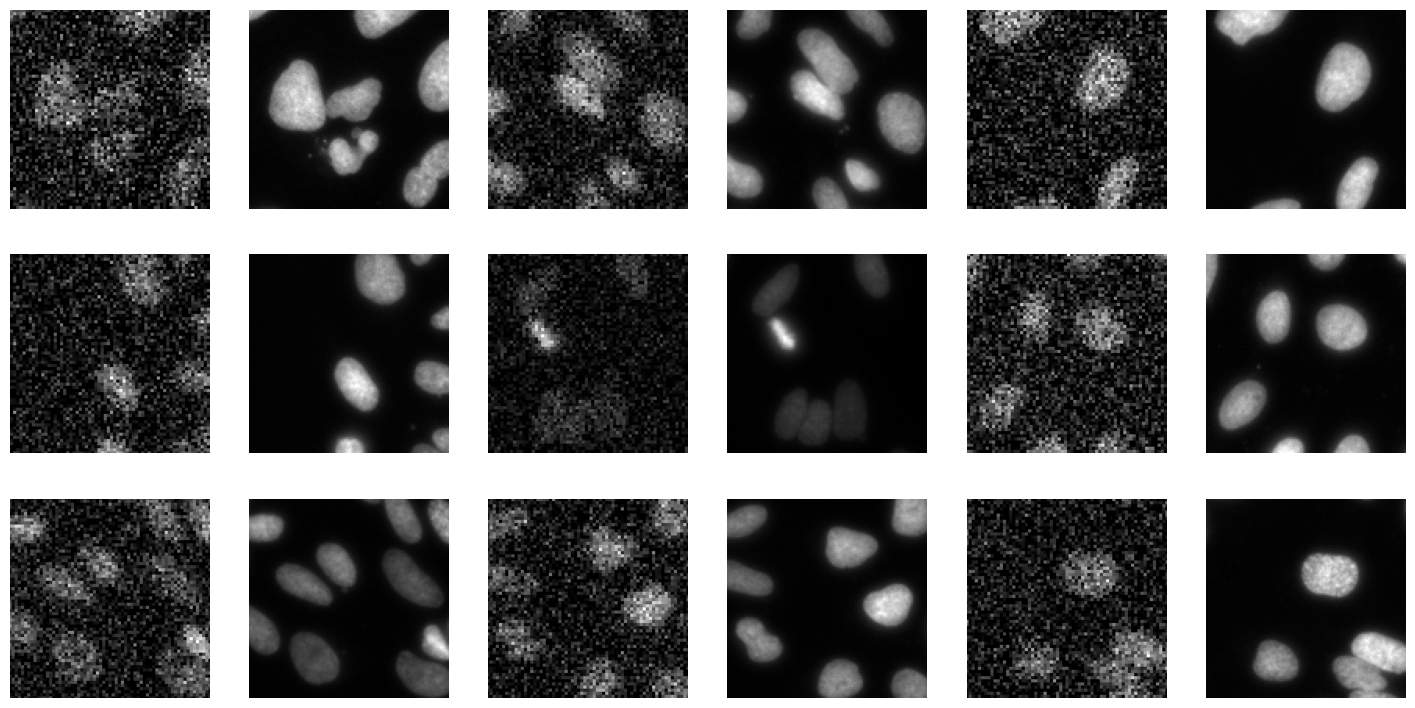

In [ ]:
data.show_batch()

### Load and train a 2D model

In [ ]:
from monai.networks.nets import UNet
model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256), strides=(1, 1, 1, 1), num_res_units=2)


In [ ]:
loss = CombinedLoss(mse_weight=0.8, mae_weight=0.1)

metrics = [MSEMetric(), MAEMetric(), SSIMMetric(2)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)


epoch,train_loss,valid_loss,MSE,MAE,SSIM,time
0,0.117512,0.073347,0.010611,0.066590,0.418010,00:15
1,0.056091,0.051336,0.010144,0.056363,0.624159,00:14
2,0.046174,0.041682,0.009452,0.051270,0.710068,00:14
3,0.043938,0.042258,0.009354,0.052179,0.704428,00:14
4,0.040266,0.046127,0.009361,0.052392,0.666007,00:14
5,0.035166,0.032958,0.005477,0.037728,0.751960,00:15
6,0.033614,0.033161,0.004932,0.037455,0.745303,00:15
7,0.029739,0.031969,0.004052,0.033369,0.746095,00:15
8,0.025354,0.027736,0.003255,0.029744,0.778420,00:15
9,0.025089,0.025022,0.003071,0.028264,0.802610,00:15


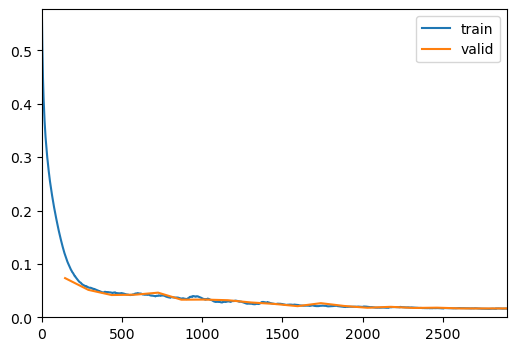

In [ ]:
trainer.fit_one_cycle(20)

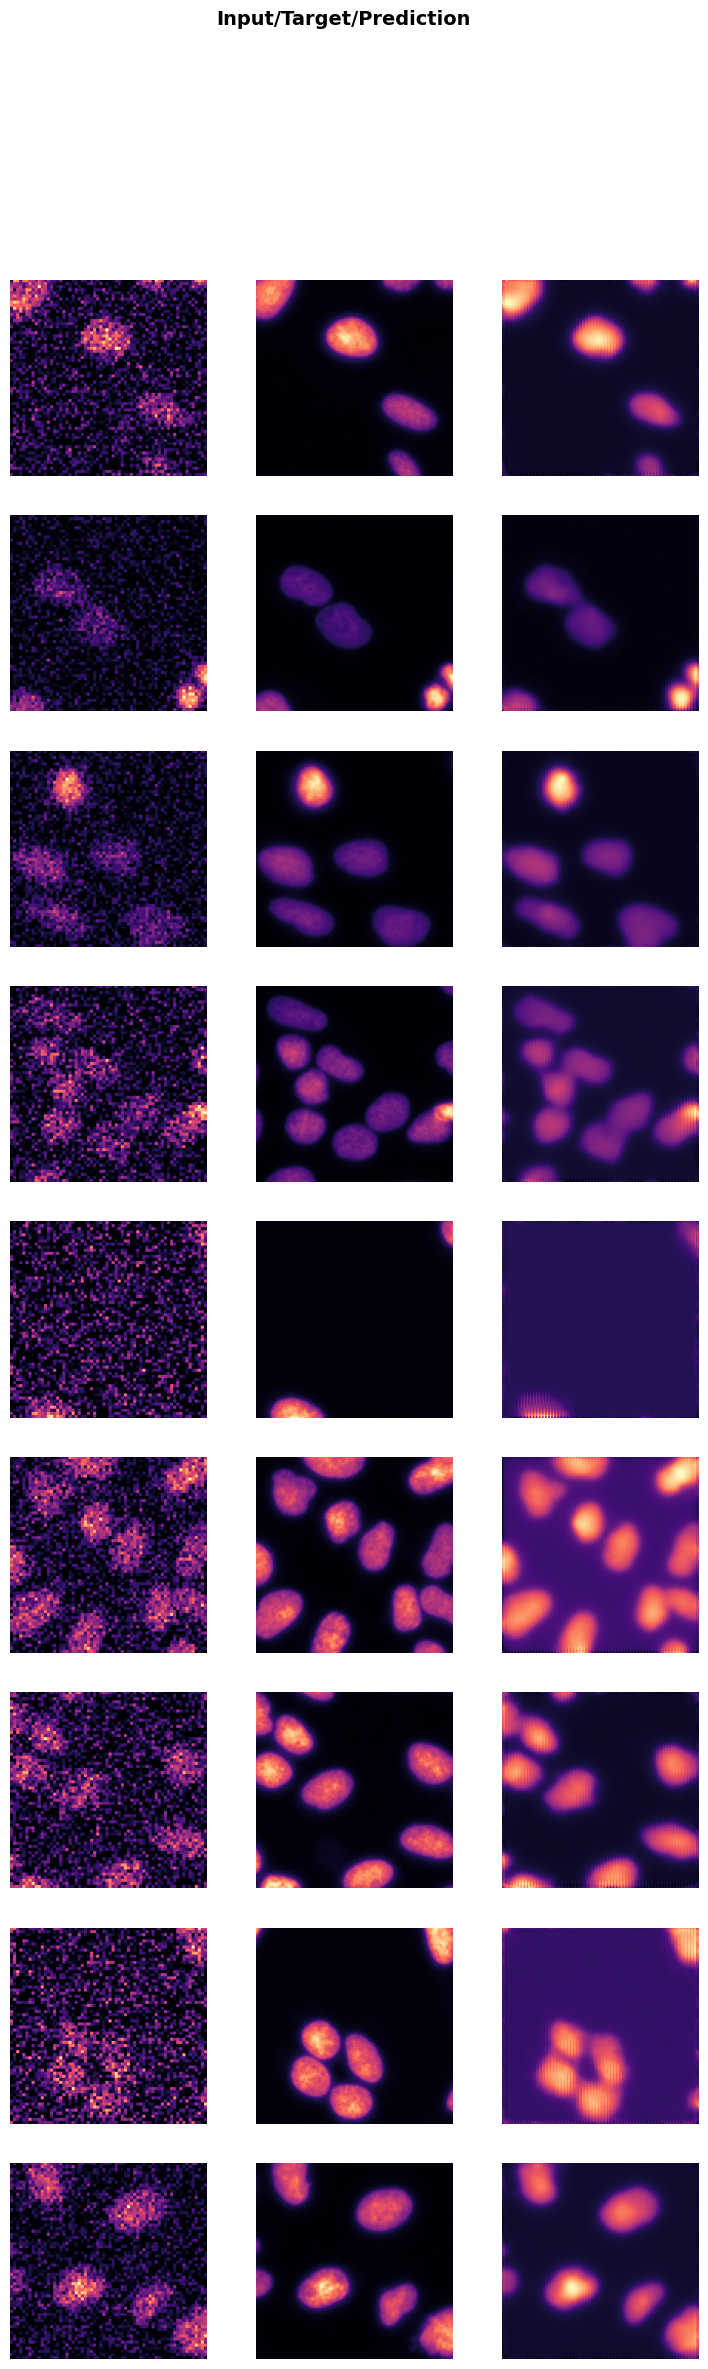

In [ ]:
trainer.show_results(cmap='magma')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

In [ ]:
test_X_path = '../_data/U2OS/128a57f165e1044e34d9a6ef46e66b3c-snr_7_binning_2.zip.unzip/test/low/'

test_data = data.test_dl(get_image_files(test_X_path), with_labels=True)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pandas as pd

def evaluate_model(trainer, test_data, loss, metrics=None, bw_method=0.3, show_graph=True, show_table=True, show_results=True, as_dataframe=True, cmap='magma'):
    """
    Calculate and optionally plot the distribution of loss values from predictions
    made by the trainer on test data, with an optional table of key statistics.

    Parameters:
        - trainer: The model trainer object with a get_preds method.
        - test_data: DataLoader containing test data.
        - loss: Loss function to evaluate prediction-target pairs.
        - metrics: Single metric or a list of metrics to evaluate. Default is None.
        - bw_method: Bandwidth method for KDE. Default is 0.3.
        - show_graph: Boolean flag to show the histogram and KDE plot. Default is True.
        - show_table: Boolean flag to show the statistics table. Default is True.
        - show_results: Boolean flag to show model results on test data. Default is True.
        - as_dataframe: Boolean flag to display table as a DataFrame. Default is True.
        - cmap: Colormap for visualization. Default is 'magma'.
    """

    if show_results:
        trainer.show_results(dl=test_data, cmap=cmap)
        
    # Get predictions and targets from the trainer
    p, t = trainer.get_preds(dl=test_data)

    # Calculate loss for each prediction-target pair
    losses = compute_losses(p, t, loss)
    loss_stats = calculate_statistics(losses)
    loss_name = loss.__class__.__name__  # Get loss function name
    if show_graph:
        plot_histogram_and_kde(losses, loss_stats, bw_method, loss_name)
    if show_table:
        display_statistics_table(loss_stats, loss_name, as_dataframe=as_dataframe)
            
    if metrics is not None:
            if not isinstance(metrics, list):
                metrics = [metrics]
            # Loop through each metric
            for metric in metrics:
                # Calculate metric values for each prediction-target pair
                metric_values = compute_metric(p, t, metric)
                metric_stats = calculate_statistics(metric_values)                
                # Get the name of the metric function
                metric_name = getattr(metric, 'func', metric).__name__  # Support AvgMetric or regular functions                
                if show_graph:
                    plot_histogram_and_kde(metric_values, metric_stats, bw_method, metric_name)
                if show_table:
                    display_statistics_table(metric_stats, metric_name, as_dataframe=as_dataframe)




def compute_losses(predictions, targets, loss_fn):
    """
    Compute the loss for each prediction-target pair.
    """
    return [loss_fn(p.unsqueeze(0), t.unsqueeze(0)).item() for p, t in zip(predictions, targets)]


def compute_metric(predictions, targets, metric_fn):
    """
    Compute the metric for each prediction-target pair.
    """
    return [metric_fn.func(p.unsqueeze(0), t.unsqueeze(0)).item() for p, t in zip(predictions, targets)]


def calculate_statistics(data):
    """
    Calculate key statistics for the data.
    """
    return {
        "Mean": np.mean(data),
        "Median": np.median(data),
        "Standard Deviation": np.std(data),
        "Min": np.min(data),
        "Max": np.max(data),
        "Q1": np.percentile(data, 25),
        "Q3": np.percentile(data, 75),
    }


def format_sig(value):
    """
    Format numbers with two significant digits.
    """
    if value == 0:
        return "0"
    elif abs(value) < 0.01 or abs(value) > 100:
        return f"{value:.2e}"  # 2 significant digits in scientific notation
    else:
        return f"{value:.2g}"  # Standard notation with 2 significant figures


def plot_histogram_and_kde(data, stats, bw_method, loss_name):
    """
    Plot the histogram and KDE of the data with key statistics marked.
    """
    kde = gaussian_kde(data, bw_method=bw_method)
    x = np.linspace(min(data), max(data), 1000)
    y = kde(x)

    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=30, density=True, color='gray', edgecolor='white', alpha=0.5)
    plt.plot(x, y, color='maroon', lw=2)
    plt.fill_between(x, y, color='maroon', alpha=0.3)

    # Add vertical lines for key statistics with formatted significant digits
    plt.axvline(stats["Mean"], color='red', linestyle='--', linewidth=1.5, label=f'Mean: {format_sig(stats["Mean"])}')
    plt.axvline(stats["Median"], color='green', linestyle='--', linewidth=1.5, label=f'Median: {format_sig(stats["Median"])}')
    plt.axvline(stats["Q1"], color='purple', linestyle=':', linewidth=1.5, label=f'Q1: {format_sig(stats["Q1"])}')
    plt.axvline(stats["Q3"], color='purple', linestyle=':', linewidth=1.5, label=f'Q3: {format_sig(stats["Q3"])}')

    # Display min, max, std deviation as text on the plot
    plt.text(stats["Mean"] + stats["Standard Deviation"], 0.1, f'Std Dev: {format_sig(stats["Standard Deviation"])}', color='black', fontsize=10)
    plt.text(stats["Min"], 0.02, f'Min: {format_sig(stats["Min"])}', color='black', fontsize=10, ha='center')
    plt.text(stats["Max"], 0.02, f'Max: {format_sig(stats["Max"])}', color='black', fontsize=10, ha='center')

    # Add loss function name to the title
    plt.title(f"Combined Histogram and KDE with Statistics\n{loss_name}")
    plt.xlabel("Loss Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


def display_statistics_table(stats, loss_name, as_dataframe=True):
    """
    Display a table of the key statistics.
    """
    if as_dataframe:
        # Convert statistics to a DataFrame and display
        df = pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])
        df.index.name = f"{loss_name}"
        display(df)
    else:
        fig, ax = plt.subplots(figsize=(5, 2))
        ax.axis("off")
        
        # Header title row
        table_data = [[f"{loss_name}", ""]]
        table_data += [[key, format_sig(value)] for key, value in stats.items()]
        
        table = ax.table(cellText=table_data, colLabels=["Statistic", "Value"], cellLoc="center", loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)
        
        # Style for header row
        header = table[0, 0]
        header.set_fontsize(12)
        header.set_text_props(weight="bold")
        plt.show()


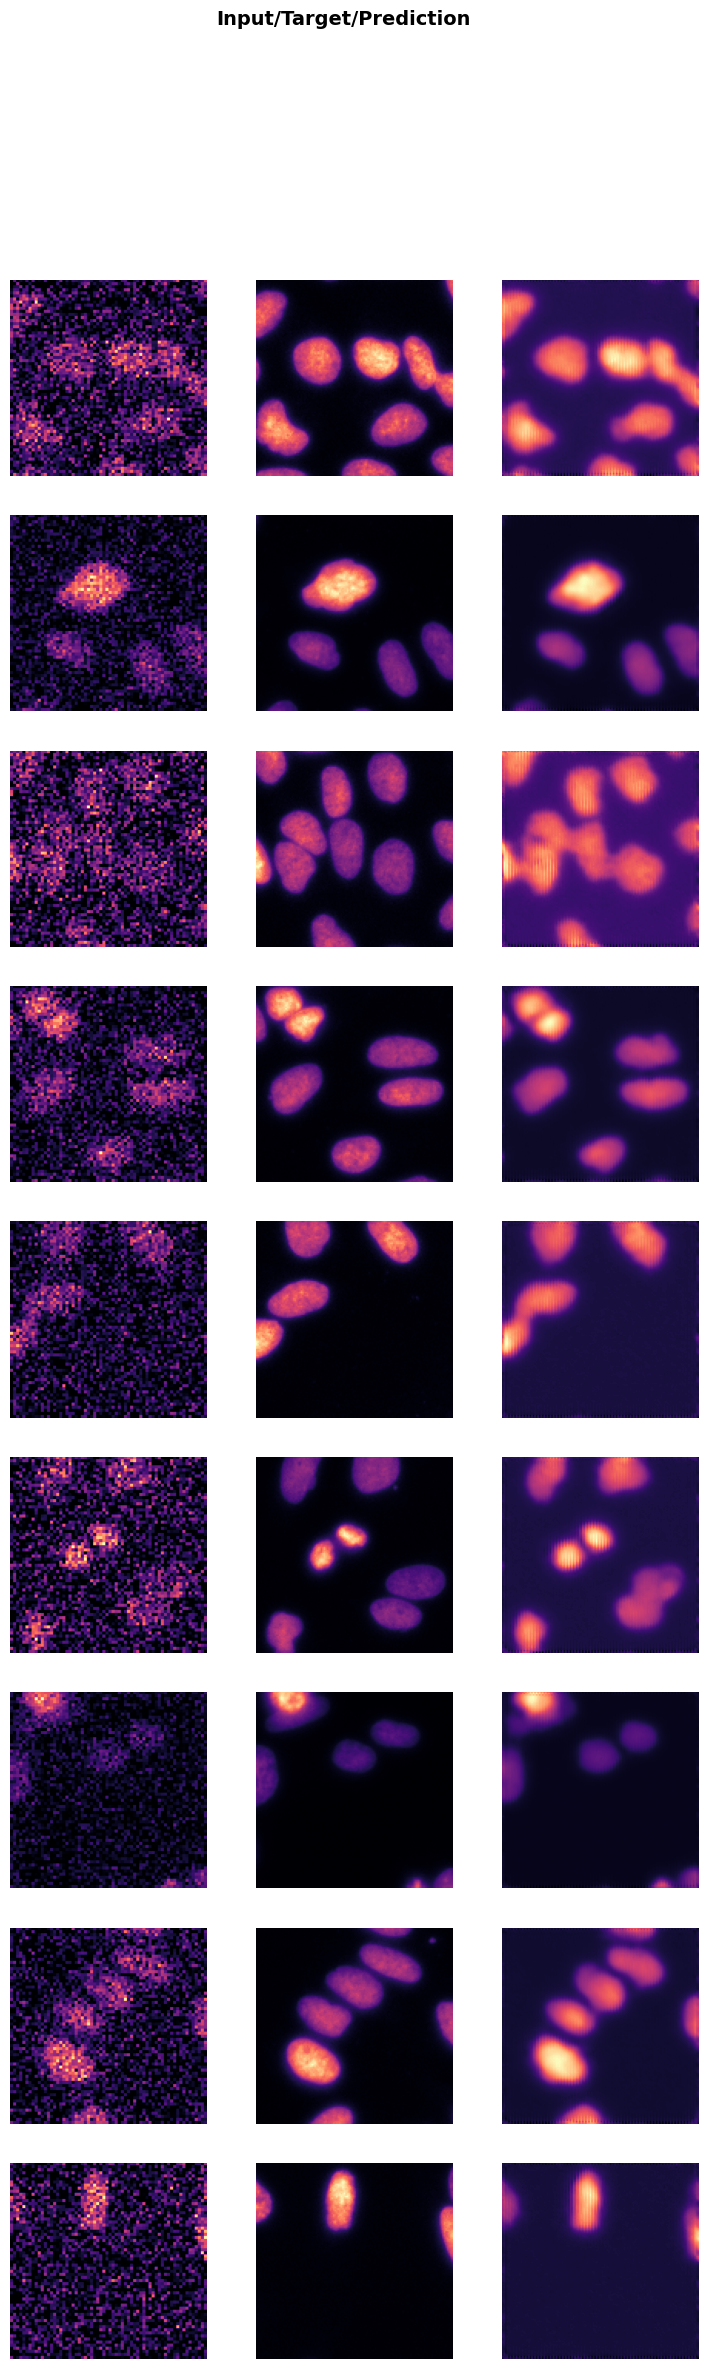

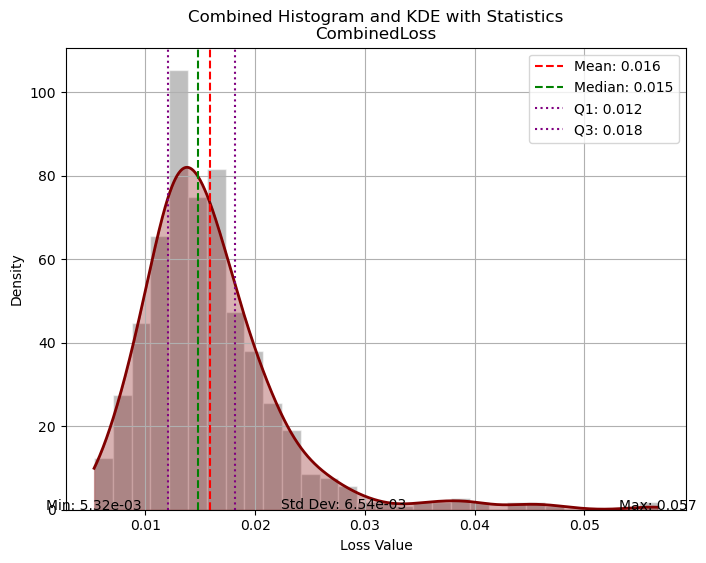

,Value
CombinedLoss,
Mean,0.015841
Median,0.014748
Standard Deviation,0.006538
Min,0.005318
Max,0.056696
Q1,0.012043
Q3,0.018140


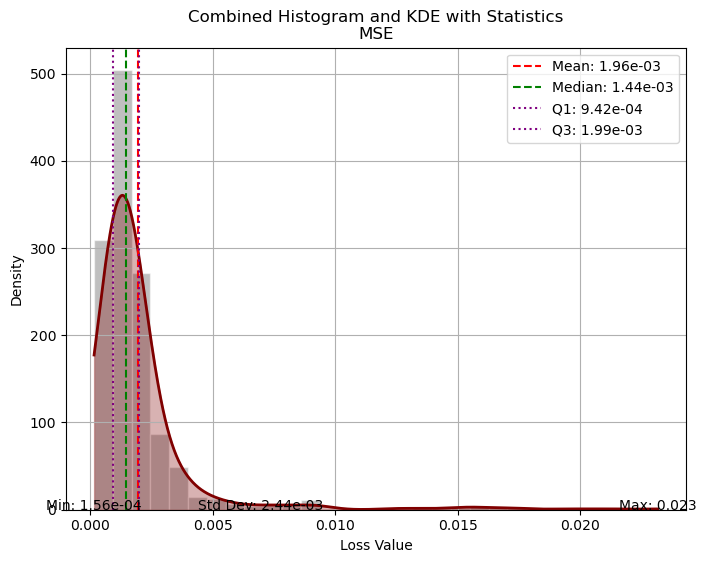

,Value
MSE,
Mean,0.001965
Median,0.001444
Standard Deviation,0.002441
Min,0.000156
Max,0.023172
Q1,0.000942
Q3,0.001985


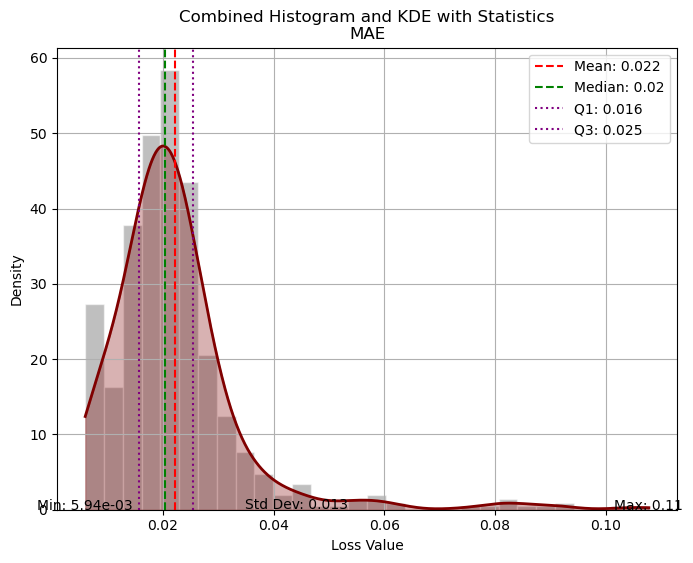

,Value
MAE,
Mean,0.022165
Median,0.020348
Standard Deviation,0.012684
Min,0.005941
Max,0.107775
Q1,0.015570
Q3,0.025371


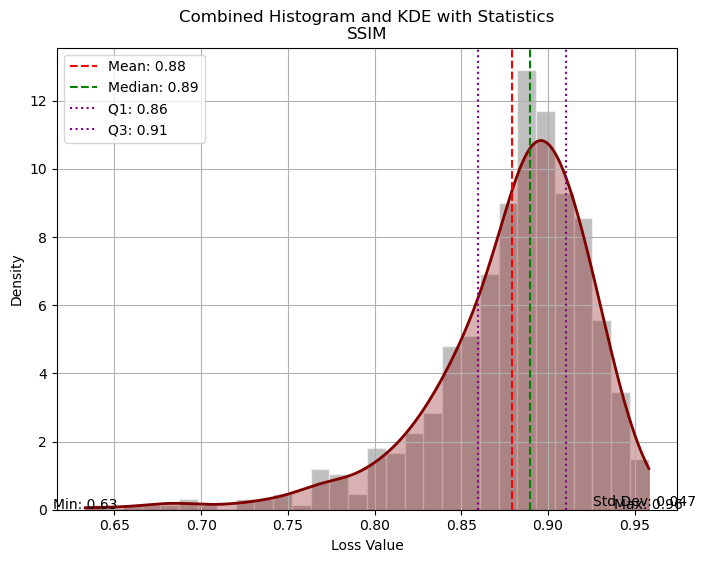

,Value
SSIM,
Mean,0.879476
Median,0.889308
Standard Deviation,0.046674
Min,0.633176
Max,0.958074
Q1,0.859496
Q3,0.910237


In [ ]:
s = evaluate_model(trainer, test_data, loss, metrics, show_graph=True, show_table=True)
